# Compile Local Environment

Run the two following cells (shift + enter) to initialize the local file path and import the Viewer Module.

In [1]:
import sys
from pathlib import Path

# Notebook's working directory (the folder containing the .ipynb)
notebook_dir = Path().resolve()

# Project root = parent of the notebook folder
project_root = notebook_dir.parent

# src directory
src_path = project_root / "src"
dat_path = project_root / "data"

# Prepend src/ to sys.path
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("src path added:", src_path)
print("test data path:", dat_path)

src path added: C:\Users\cxh52226\source\repos\DIAD_Notebooks\DIAD_Diffraction\src
test data path: C:\Users\cxh52226\source\repos\DIAD_Notebooks\DIAD_Diffraction\data


In [2]:
from diffraction_data_analysis_azimuthal import DiffractionDataAnalysis_Azzimuthal

# Diffraction Data Analysis
1. Define the object: > [Viewer] = DiffractionDataAnalysis(diff_path, raw_KB_2D_map, img_path, out_path, proj_idx)
2. Run file importer: > [Viewer].InputOutput()

Note: if running the InputOutput without definitions of the paths ensure the base path is consistent with your system definiing the [Viewer].VisitPath variable to a sensible start searching point (e.g., the visit folder)
 
Object parameters:
- "diff_path"  ... Diffraction postprocessing nxs data
- "kbmap_path" ... raw kb 2D map for flux normalization
- "img_path"   ... Imaging nxs data (either radiography raw, tomography raw, tomography reconstruction)
- "out_path"   ... Output directory and file root path
- "projection_index" ... Optional index of the projection (this is used with radiography datasets to chose an arbitrary projection)

Missing parameters will be requested running 'InputOutput()'

An arbitrary partial list of parameters can be prompted entring the parametyer name (see above) followed by '=' parameter_value.

3. Run data analsys :
   - Azimuthal Profile Self-analsysis > [Viewer].ImageCorrelatedCrystallography_Azimuthal(start_scattering_rang, end_scattering_range, Chebichef_order (i.e., 1), Error_Threshold (e.g., 0.1), ColorRange_Percentile (e.g. 10))
   - Azimuthal Profile Individual Peak Analysis >  [Viewer].ImageCorrelatedCrystallography_Azimuthal(start_scattering_range, end_scattering_range, Chebichef_order (i.e., 1), Error_Threshold (e.g., 0.1), ColorRange_Percentile (e.g. 10),
   Output='view'/'save', Mean_min, Mean_max, Area_min, Area_max, FWHM_min, FWHM_max, Mean_relax, Base_reference (DiffractionDataAnalysis reference object for normalization)
   - Azimuthal Profile Individual Peak Analysis >  [Viewer].ImageCorrelatedCrystallography_Azimuthal_Explore(start_scattering_range, end_scattering_range, Chebichef_order (i.e., 1), Error_Threshold (e.g., 0.1), ColorRange_Percentile (e.g. 10))
   - Azimuthal Profile Relative Peak Analysis >  [Viewer].ImageCorrelatedCrystallography_Azimuthal_Relative(start_scattering_range_I, end_scattering_range_I, start_scattering_range_II, end_scattering_range_II, Chebichef_order (i.e., 1), Error_Threshold (e.g., 0.1), ColorRange_Percentile (e.g. 10))
   - Cake & Cake_Flipped Profile Self-analsysis > [Viewer].ImageCorrelatedCrystallography_Cake(start_scattering_rang, end_scattering_range, Chebichef_order (i.e., 1), Error_Threshold (e.g., 0.1), ColorRange_Percentile (e.g. 10))
   - Cake & Cake_Flipped Profile Individual spot analysis (Peak Area) >  [Viewer].ImageCorrelatedCrystallography_Cake_ExploreArea(start_scattering_range, end_scattering_range, Chebichef_order (i.e., 1), Error_Threshold (e.g., 0.1), ColorRange_Percentile (e.g. 10))

Note: the explore modules allow interactive view of the reference peak by clicking on the spot of interest in the imaging view

In [3]:
Relative = DiffractionDataAnalysis_Azzimuthal(
    dat_path / "mg12123-1" / "processed" / "k11-66526-diffraction-DiffInt_AzzTxt.nxs",
    dat_path / "mg12123-1" / "nexus" / "66350",
    dat_path / "mg12123-1" / "nexus" / "k11-66525.nxs",
    dat_path / "mg12123-1" / "processing" / "output")
Relative.InputOutput()

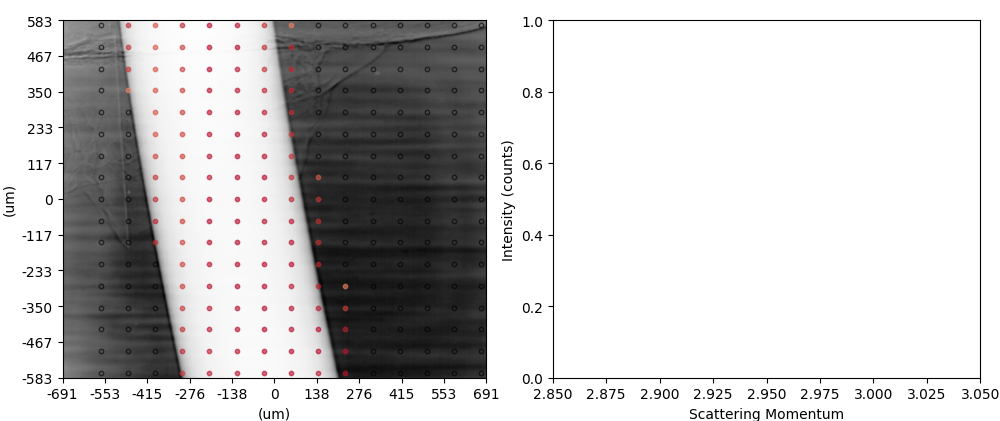

In [4]:
Relative.ImageCorrelatedCrystallography_Azimuthal_Explore(2.85,3.05,1,0.25,-1)

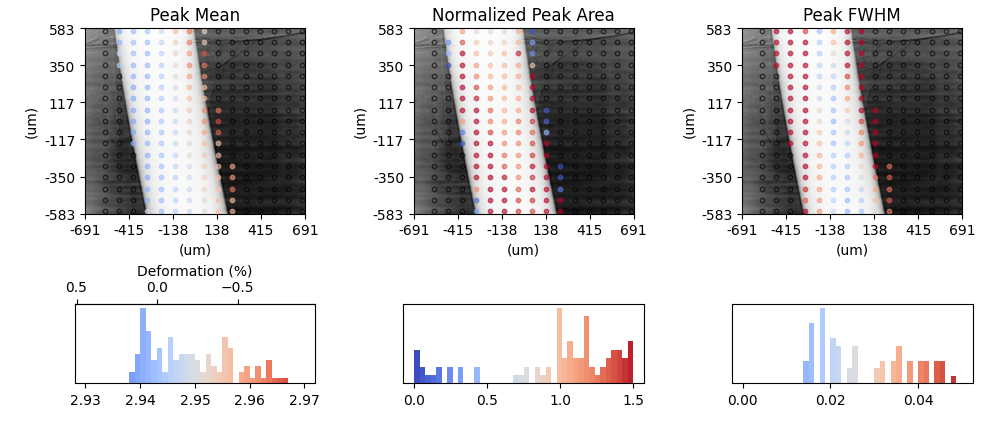

In [5]:
Relative.ImageCorrelatedCrystallography_Azimuthal(2.85,3.05,1,0.25,-1,'view',
                                                     Mean_min=2.93, Mean_max=2.97,
                                                     Area_min=0.0, Area_max=1.5,
                                                     FWHM_min=0.00, FWHM_max=0.05,
                                                     Mean_relax=2.943)

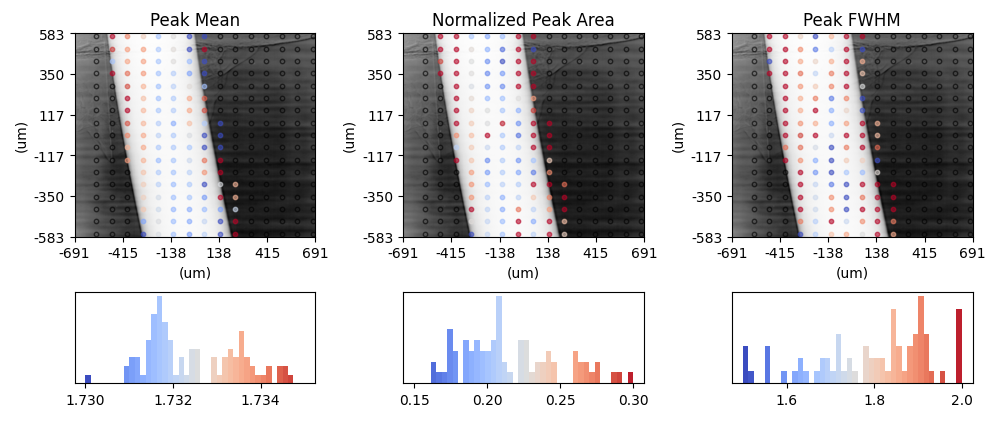

In [12]:
Relative.ImageCorrelatedCrystallography_Azimuthal_Relative(2.85,3.05, 5.00, 5.20,1,0.25,-1,'view',
                                                             Mean_min=1.730, Mean_max=1.735,
                                                             Area_min=0.15, Area_max=0.3,
                                                             FWHM_min=1.5, FWHM_max=2.0)

In [11]:
Reference = DiffractionDataAnalysis_Azzimuthal(
    dat_path / "mg12123-1" / "processed" / "k11-66526-diffraction-DiffInt_AzzTxt.nxs",
    dat_path / "mg12123-1" / "nexus" / "66350",
    dat_path / "mg12123-1" / "nexus" / "k11-66525.nxs",
    dat_path / "mg12123-1" / "processing" / "output")
Reference.InputOutput()

In [4]:
Running = DiffractionDataAnalysis_Azzimuthal(
    dat_path / "mg12123-1" / "processed" / "k11-66526-diffraction-DiffInt_AzzTxt.nxs",
    dat_path / "mg12123-1" / "nexus" / "66350",
    dat_path / "mg12123-1" / "nexus" / "k11-66525.nxs",
    dat_path / "mg12123-1" / "processing" / "output")
Running.InputOutput()

In [5]:
Qmin = 2.85
Qmax = 3.05

cheb = 1
gofx = 0.25
thrc = -1

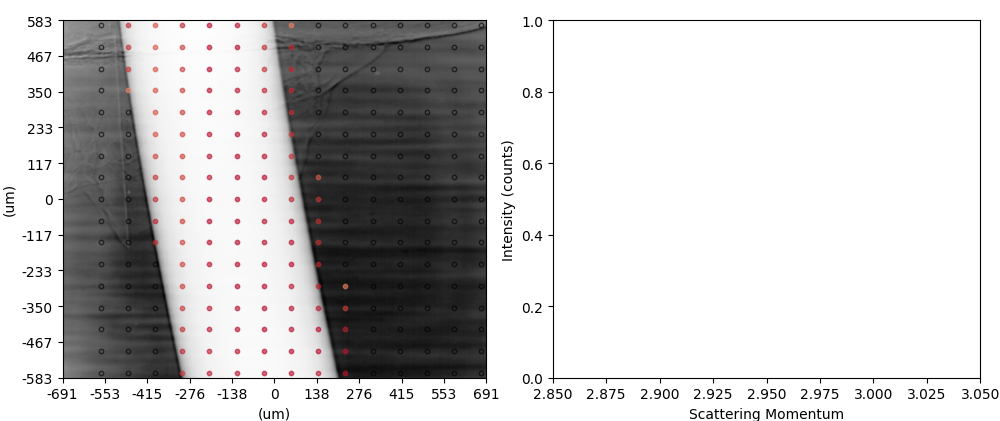

In [6]:
Reference.ImageCorrelatedCrystallography_Azimuthal_Explore(Qmin,Qmax,cheb,gofx,thrc)

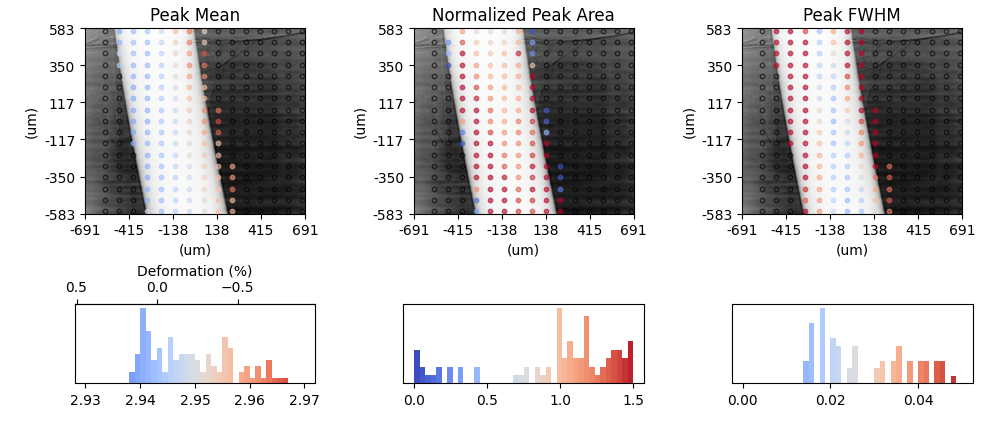

In [7]:
Reference.ImageCorrelatedCrystallography_Azimuthal(Qmin,Qmax,cheb,gofx,thrc,'view',
                                                     Mean_min=2.93, Mean_max=2.97,
                                                     Area_min=0.0, Area_max=1.5,
                                                     FWHM_min=0.00, FWHM_max=0.05,
                                                     Mean_relax=2.943)

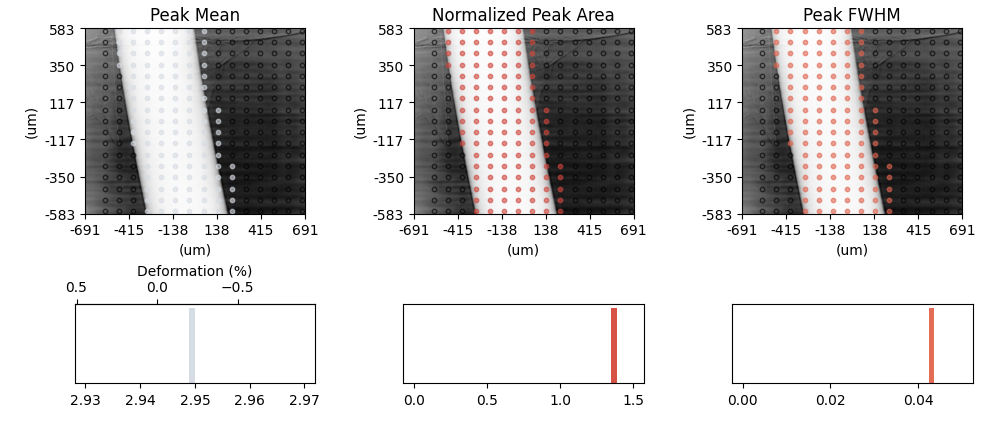

In [8]:
Running.ImageCorrelatedCrystallography_Azimuthal(Qmin,Qmax,cheb,gofx,thrc,'view',
                                                     Mean_min=2.93, Mean_max=2.97,
                                                     Area_min=0.0, Area_max=1.5,
                                                     FWHM_min=0.00, FWHM_max=0.05,
                                                     Mean_relax=2.943, Base_reference = Reference)

# Automated Analysis and Visualization of Data Sequences
The following cells disply how to use the analysis module to process multiple datasets (saving the output plots as tiff files) and reload the results in a viewer that allows to scrol acrss the datasets and saving them as a single movie file

In [9]:
Cycle = "Sample"

pairs = [(66525, 66526),
         (66537, 66538),]

In [10]:
for idx, (iM,iD) in enumerate(pairs):
    Runnning_Viewer = DiffractionDataAnalysis_Azzimuthal(
        dat_path / "mg12123-1" / "processed" / f"k11-{iD}-diffraction-DiffInt_AzzTxt.nxs",
        dat_path / "mg12123-1" / "nexus" / "66350",
        dat_path / "mg12123-1" / "nexus" / f"k11-{iM}.nxs",
        dat_path / "mg12123-1" / "processing" / f"{Cycle}_{idx}")
    Runnning_Viewer.InputOutput()
    Runnning_Viewer.ImageCorrelatedCrystallography_Azimuthal(Qmin,Qmax,cheb,gofx,thrc,'save',
                                                     Mean_min=2.93, Mean_max=2.97,
                                                     Area_min=0.0, Area_max=1.5,
                                                     FWHM_min=0.00, FWHM_max=0.05,
                                                     Mean_relax=2.943)
    del Runnning_Viewer
    print(f"Complete processing frame {idx}")

Complete processing frame 0
Complete processing frame 1


In [11]:
import os
import glob
import imageio
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from PIL import Image

# --- Configuration ---
folder = dat_path / "mg12123-1" / "processing"

def Explore_Sequence(folder, Cycle, Data, pairs):
    # Force local interactive backend for this plotting session
    try:
        plt.switch_backend("module://ipympl.backend_nbagg")
    except Exception:
        # fallback if ipympl not available
        plt.switch_backend("nbAgg")
    
    # --- Load images ---
    images = []
    for idx, (iM, iD) in enumerate(pairs):
        path = folder / f"{Cycle}_{idx}_{Data}.tiff"
        img = Image.open(path)
        images.append(img)
    
    fig = plt.figure(figsize=(10, 8))
    
    # Slider (keep this as the anchor for width and horizontal position)
    ax_slider = plt.axes([0.25, 0.08, 0.50, 0.03])   # (left, bottom, width, height)
    slider = Slider(ax_slider, "Frame", 0, len(images)-1, valinit=0, valstep=1)
    
    # Button: centered and ≈1/3 smaller height
    BTN_W = 0.18
    BTN_H = 0.04   # was 0.06 → ~1/3 smaller
    BTN_BOTTOM = 0.02
    
    # Compute centered left position
    center_left = 0.5 - BTN_W / 2.0
    ax_button = plt.axes([center_left, BTN_BOTTOM, BTN_W, BTN_H])
    button = Button(ax_button, "Save Movie")
    
    # Image axes: width/left equal to slider; minimal gap above slider
    ax_img = plt.axes([0.25, 0.15, 0.50, 0.80])  # initial; will be aligned below
    img_display = ax_img.imshow(images[0], cmap="gray")
    ax_img.axis("off")
    
    def layout_match_image_to_slider():
        sbox = ax_slider.get_position()   # Bbox in figure coordinates
        left = sbox.x0
        width = sbox.width
    
        # Place image just above the slider with a small gap
        gap = 0.0                        # ↓ reduce/increase to taste
        bottom = sbox.y0 + sbox.height + gap
    
        # Fill remaining height up to near the top
        top_margin = 0.03                  # small margin from top of figure
        height = 1.0 - bottom - top_margin
        height = max(0.05, height)         # guard: keep positive
    
        ax_img.set_position([left*0.8, bottom*0.6, width*1.2, height*1.2])
    
        # Re-center the button (in case figure width changes)
        btn_left = 0.5 - BTN_W / 2.0
        ax_button.set_position([btn_left, BTN_BOTTOM, BTN_W, BTN_H])
    
    # Initial alignment
    layout_match_image_to_slider()
    
    def on_resize(event):
        layout_match_image_to_slider()
        fig.canvas.draw_idle()
    
    fig.canvas.mpl_connect("resize_event", on_resize)
    
    def update(val):
        idx = int(slider.val)
        img_display.set_data(images[idx])
        fig.canvas.draw_idle()
    
    slider.on_changed(update)
    
    def save_movie(event):
        out_file = os.path.join(folder, f"{Cycle}_{Data}.mp4")
        print(f"Saving movie to {out_file} ...")
        imageio.mimsave(out_file, images, fps=5)
    
    button.on_clicked(save_movie)

    plt.ion()
    plt.show()

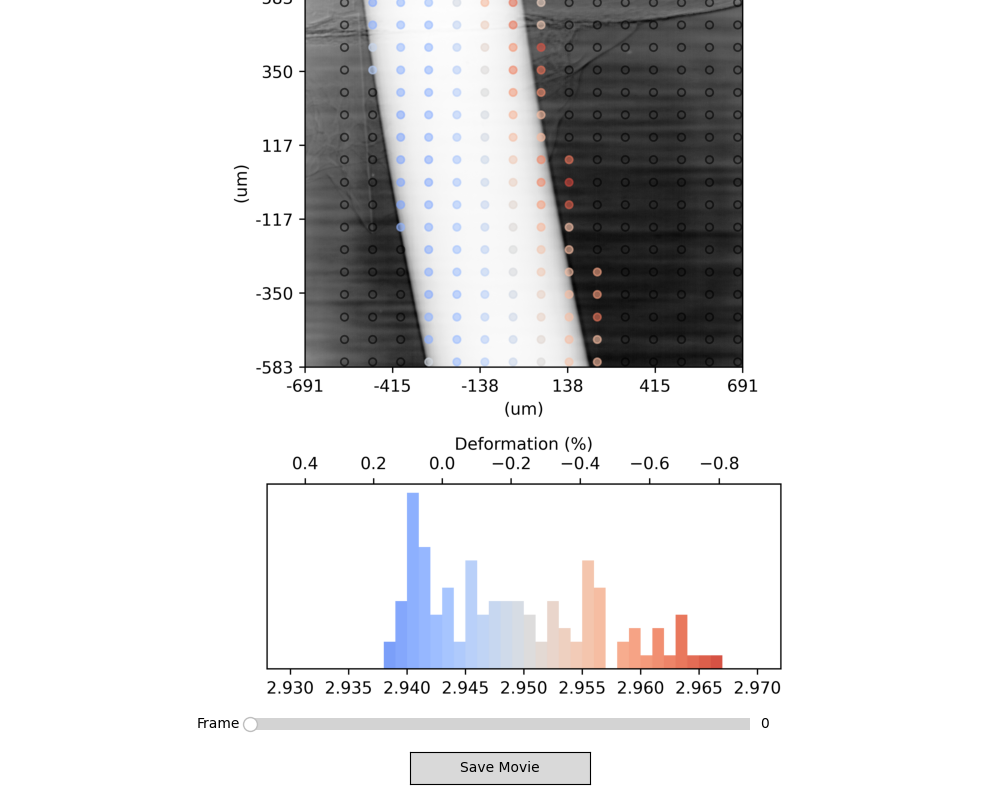

In [12]:
Explore_Sequence(folder, Cycle, "Mean", pairs)

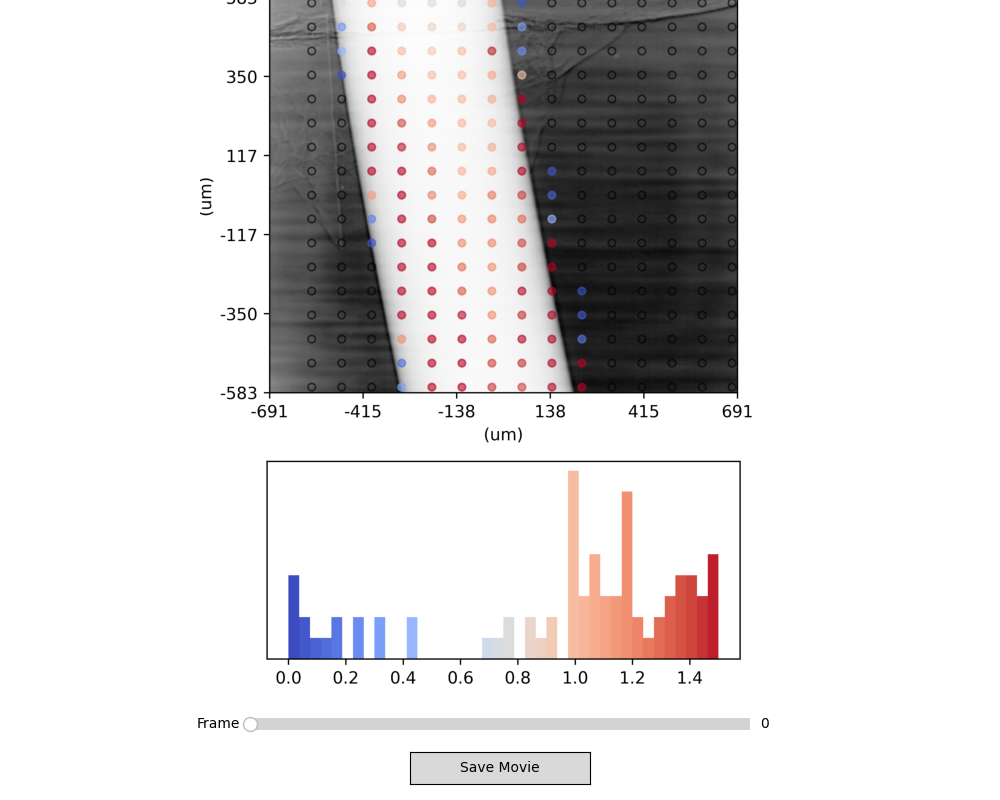

In [13]:
Explore_Sequence(folder, Cycle, "Area", pairs)

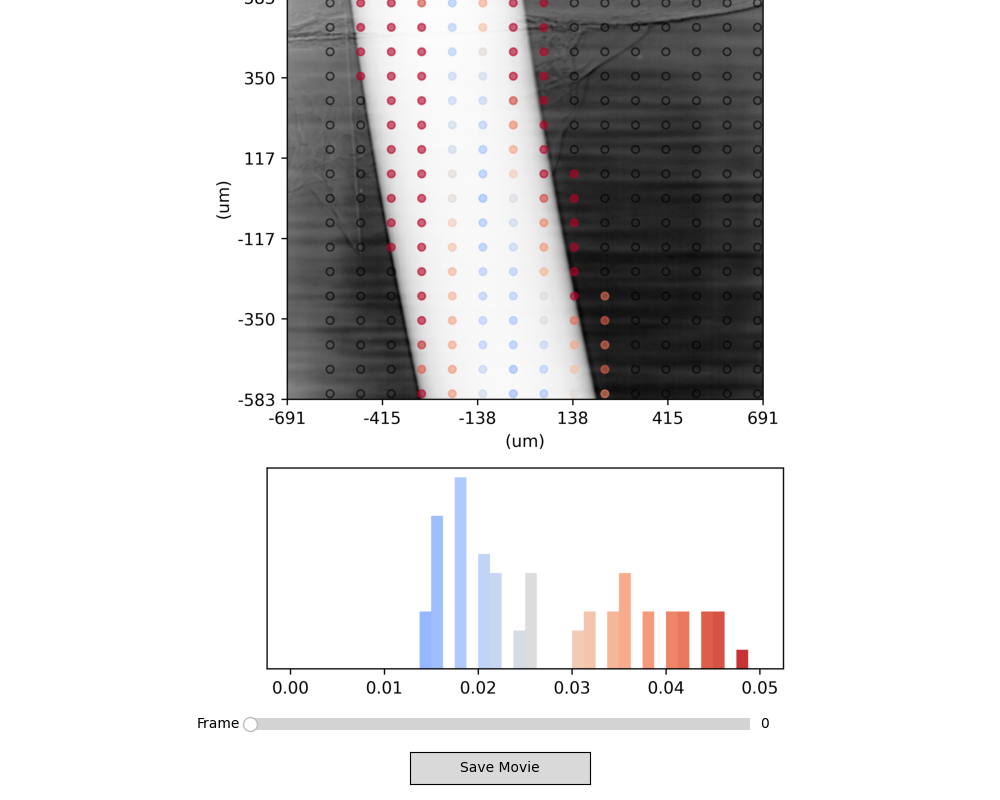

In [14]:
Explore_Sequence(folder, Cycle, "FWHM", pairs)